# 06 — Modelo lineal del tiempo de simulación

## Por qué

Antes de tirar una corrida grande (cientos de miles a millones de cascadas) es razonable poder **predecir cuánto va a tardar** con error de minutos, no de horas. Una regresión lineal sobre las corridas pequeñas ya hechas nos da esa estimación y, de paso, separa dos efectos físicos del cómputo:

$$ t(N) = a + b\,N $$

- **$a$ (intersección, segundos):** overhead fijo por corrida. Levantar el container Docker, arrancar el binario de CORSIKA, leer la steering, inicializar tablas, cerrar archivos. **No depende de $N$**.
- **$b$ (pendiente, segundos/cascada):** costo marginal de cada cascada hadrónica completa. Esto sí está dominado por la física: con un primario de 10 GeV–100 TeV, la mayor parte del tiempo se va en propagar la cascada electromagnética y los hadrones secundarios.

## Qué predice

Dado el modelo, la duración esperada para una corrida nueva de $N^*$ cascadas es $\hat t(N^*) = a + b\,N^*$, con incertidumbre $\sigma_{\hat t}$ derivada del error estándar del fit.

## Qué buscar

- **Linealidad limpia**: $R^2 \gtrsim 0.99$ en log-log y residuos sin patrón. Si la dispersión crece con $N$ (heterocedasticidad) puede ser jitter del host.
- **$a$ comparable a $b\cdot N$ sólo a $N$ pequeño**: si para $N=10^4$ ya $a \ll bN$, el overhead deja de importar y la extrapolación a $N$ grandes es confiable.
- **Distintos hosts → distinto $b$**: el costo por cascada es propiedad de la máquina (CPU, frecuencia). Si la corrida grande va a ser en server, hay que ajustar **sólo con los puntos del server**.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## Los datos

`sim/runs.csv` es el manifest único de corridas. Cada `make corsika-run VOLCAN=... NSHOW=...` (local o vía `make server-run`) appendea una fila con todo el contexto: `runnr, volcan, detector_pos, started_at, nshow, duration_sec, host, he_model, obslev_cm, magnet_h/v, atmod, status, ...`. Para refrescar con corridas del server: `make sync-runs`.

Filtramos `status == 'ok'`. Para el fit usamos `(NSHOW, duration_sec)` agrupado por `host` — el costo por cascada es propiedad de la máquina; mezclar laptop con server contamina la pendiente.

In [2]:
df = pd.read_csv(REPO_ROOT / 'sim' / 'runs.csv')
df = df[df['status'] == 'ok'].copy()
# Solo runs con duration_sec medido (backfills históricos sin .lst de timings pueden quedar vacíos)
df = df.dropna(subset=['duration_sec', 'host', 'nshow'])
df['duration_sec'] = df['duration_sec'].astype(int)
df['nshow'] = df['nshow'].astype(int)
df = df.sort_values('nshow').reset_index(drop=True)

df['dur_min'] = df['duration_sec'] / 60
df['sec_per_shower'] = df['duration_sec'] / df['nshow']

print(f"{len(df)} corridas, hosts: {sorted(df['host'].unique())}, "
      f"volcanes: {sorted(df['volcan'].unique())}, "
      f"he_models: {sorted(df['he_model'].dropna().astype(int).unique())}")
df[['runnr', 'volcan', 'started_at', 'host', 'nshow', 'duration_sec', 'dur_min',
    'sec_per_shower', 'he_model']]

7 corridas, hosts: ['alcyon'], volcanes: ['fuego'], he_models: [np.int64(1)]


,runnr,volcan,started_at,host,nshow,duration_sec,dur_min,sec_per_shower,he_model
0,2001,fuego,2026-05-18T05:03:53-06:00,alcyon,100,18,0.300000,0.180000,1
1,2010,fuego,2026-05-18T05:04:46-06:00,alcyon,1000,25,0.416667,0.025000,1
2,2020,fuego,2026-05-18T07:22:29-06:00,alcyon,2000,25,0.416667,0.012500,1
3,2060,fuego,2026-05-18T07:23:29-06:00,alcyon,6000,48,0.800000,0.008000,1
4,2100,fuego,2026-05-18T05:06:24-06:00,alcyon,10000,63,1.050000,0.006300,1
5,2300,fuego,2026-05-18T07:03:51-06:00,alcyon,30000,125,2.083333,0.004167,1
6,2900,fuego,2026-05-18T07:10:06-06:00,alcyon,90000,296,4.933333,0.003289,1


## Ajuste

OLS sobre $(N_i, t_i)$ con `scipy.stats.linregress`. Devuelve pendiente, intersección, $R^2$ y errores estándar. **Filtramos por host** porque la pendiente es propiedad de la máquina: mezclar laptop con server contamina el costo por cascada.


In [3]:
def fit_host(group: pd.DataFrame) -> dict:
    x = group['nshow'].to_numpy(dtype=float)
    y = group['duration_sec'].to_numpy(dtype=float)
    res = stats.linregress(x, y)
    return {
        'host': group['host'].iloc[0],
        'n_points': len(group),
        'a_sec': res.intercept,
        'a_stderr_sec': res.intercept_stderr,
        'b_sec_per_shower': res.slope,
        'b_stderr': res.stderr,
        'r2': res.rvalue ** 2,
    }

fits = pd.DataFrame([fit_host(g) for _, g in df.groupby('host') if len(g) >= 2])
fits

,host,n_points,a_sec,a_stderr_sec,b_sec_per_shower,b_stderr,r2
0,alcyon,7,25.067741,3.279562,0.003052,0.000091,0.995598


**Cómo leer:** $b$ en s/cascada × 3600 = cascadas/hora alcanzables por ese host. $a$ es el overhead fijo de levantar Docker + CORSIKA; típicamente unos pocos segundos para containers ya buildeados.


In [4]:
for _, row in fits.iterrows():
    rate = 3600 / row['b_sec_per_shower']
    print(f"{row['host']:>10}: t = {row['a_sec']:.1f}s + {row['b_sec_per_shower']*1e3:.3f} ms/cascada "
          f"| R²={row['r2']:.4f} | throughput ≈ {rate:,.0f} cascadas/hora")

    alcyon: t = 25.1s + 3.052 ms/cascada | R²=0.9956 | throughput ≈ 1,179,575 cascadas/hora


## Visualización

Dos paneles:
1. **Lineal**: para juzgar la calidad del fit en el rango de los datos.
2. **Log-log**: para revelar curvatura escondida. Si el modelo fuera $t \propto N$, las dos rectas tienen pendiente 1 en log-log; el offset $a$ se vuelve una asíntota a la izquierda.


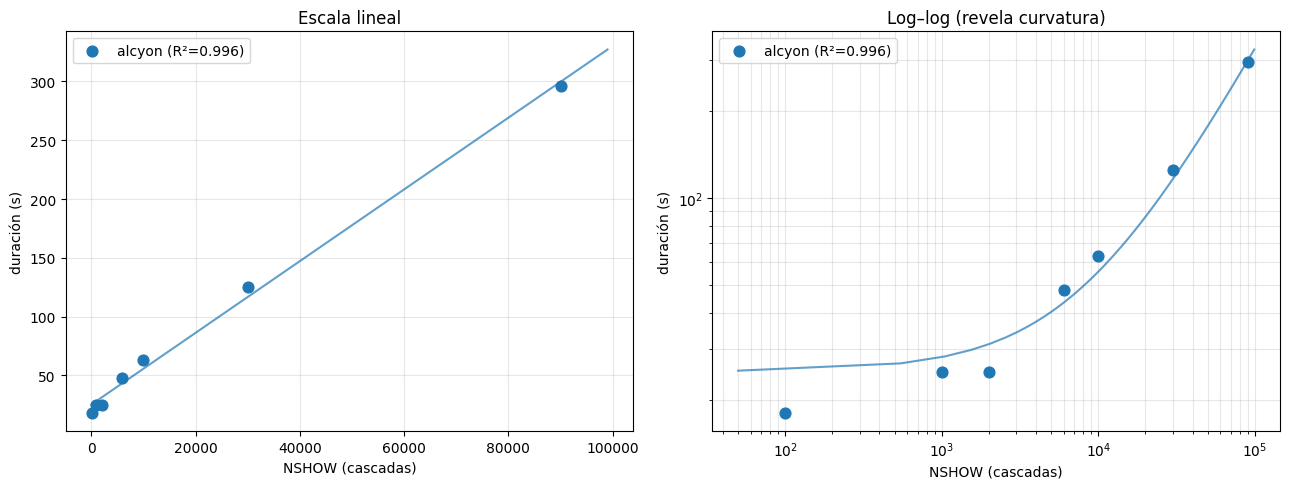

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colors = plt.cm.tab10(np.linspace(0, 1, len(fits)))
for color, (_, fit_row) in zip(colors, fits.iterrows()):
    sub = df[df['host'] == fit_row['host']]
    x = sub['nshow'].to_numpy()
    y = sub['duration_sec'].to_numpy()

    x_grid = np.linspace(x.min() * 0.5, x.max() * 1.1, 200)
    y_hat = fit_row['a_sec'] + fit_row['b_sec_per_shower'] * x_grid

    label = f"{fit_row['host']} (R²={fit_row['r2']:.3f})"
    for ax in (ax1, ax2):
        ax.scatter(x, y, color=color, s=60, zorder=3, label=label)
        ax.plot(x_grid, y_hat, color=color, alpha=0.7, lw=1.5)

ax1.set_xlabel('NSHOW (showers)')
ax1.set_ylabel('duración (s)')
ax1.set_title('Escala lineal')
ax1.grid(alpha=0.3)
ax1.legend()

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('NSHOW (showers)')
ax2.set_ylabel('duración (s)')
ax2.set_title('Log–log (revela curvatura)')
ax2.grid(alpha=0.3, which='both')
ax2.legend()

plt.tight_layout()
plt.show()

## Residuos

El $R^2$ resume bien la calidad global, pero **esconde patrones**. Un residuo $r_i = t_i - \hat t(N_i)$ que crece sistemáticamente con $N$ delata no-linealidad (overhead que escala, p.ej. I/O cuando el archivo de salida se vuelve grande). Si los residuos están centrados en 0 y dispersos sin tendencia, el modelo lineal es adecuado.


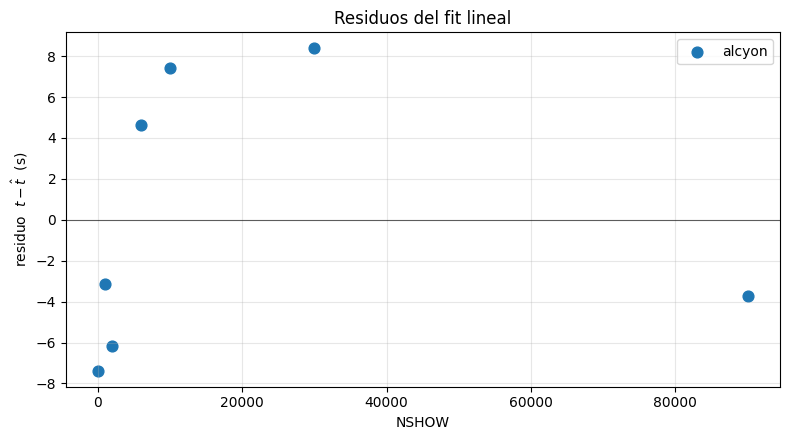

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for color, (_, fit_row) in zip(colors, fits.iterrows()):
    sub = df[df['host'] == fit_row['host']]
    x = sub['nshow'].to_numpy()
    y = sub['duration_sec'].to_numpy()
    y_hat = fit_row['a_sec'] + fit_row['b_sec_per_shower'] * x
    resid = y - y_hat
    ax.scatter(x, resid, color=color, s=60, label=fit_row['host'])

ax.axhline(0, color='k', lw=0.8, alpha=0.6)
ax.set_xlabel('NSHOW')
ax.set_ylabel('residual  $t - \\hat t$  (s)')
ax.set_title('Linear fit residuals')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Predicciones para corridas grandes

Para una corrida de $N^*$ cascadas usamos $\hat t = a + b N^*$. La incertidumbre es la propagación del error de los parámetros:

$$ \sigma_{\hat t}(N^*) = \sqrt{\sigma_a^2 + (N^*)^2\,\sigma_b^2} $$

(asumiendo $a$ y $b$ independientes — aproximación razonable; el covariance term de OLS está acotado).


In [7]:
TARGETS = [50_000, 100_000, 250_000, 500_000, 1_000_000, 5_000_000]

def fmt_dur(seconds: float) -> str:
    if seconds < 60:
        return f'{seconds:.0f} s'
    if seconds < 3600:
        return f'{seconds/60:.1f} min'
    if seconds < 86400:
        return f'{seconds/3600:.1f} h'
    return f'{seconds/86400:.2f} d'

rows = []
for _, fit_row in fits.iterrows():
    a, b = fit_row['a_sec'], fit_row['b_sec_per_shower']
    sa, sb = fit_row['a_stderr_sec'], fit_row['b_stderr']
    for N in TARGETS:
        t_hat = a + b * N
        sigma = np.sqrt(sa**2 + (N * sb)**2)
        rows.append({
            'host': fit_row['host'],
            'NSHOW': N,
            't_hat': fmt_dur(t_hat),
            '±1σ': f'±{fmt_dur(sigma)}',
            't_hat_sec': int(t_hat),
        })

pred = pd.DataFrame(rows)
pred.pivot_table(index='NSHOW', columns='host', values='t_hat', aggfunc='first')

host,alcyon
NSHOW,
50000,3.0 min
100000,5.5 min
250000,13.1 min
500000,25.9 min
1000000,51.3 min
5000000,4.2 h


In [8]:
pred[['host', 'NSHOW', 't_hat', '±1σ']]

,host,NSHOW,t_hat,±1σ
0,alcyon,50000,3.0 min,±6 s
1,alcyon,100000,5.5 min,±10 s
2,alcyon,250000,13.1 min,±23 s
3,alcyon,500000,25.9 min,±45 s
4,alcyon,1000000,51.3 min,±1.5 min
5,alcyon,5000000,4.2 h,±7.6 min


## Interpretación física del fit

**La pendiente $b$ es el invariante interesante.** No depende de la steering particular: con `ESLOPE -2.7` y `ERANGE 10 GeV – 100 TeV`, el costo medio por cascada está dominado por los primarios de baja energía (más numerosos por la pendiente del espectro) pero los pocos primarios de alta energía aportan la cola de varianza en el tiempo individual de cada cascada. El promedio empírico $b$ ya integra toda esa distribución.

**Cambiar de modelo hadrónico cambia $b$.** DPMJET-III (default) y SIBYLL 2.3e tienen costos similares; EPOS-LHC suele ser ~2× más lento; QGSJETIII-01 a veces ~30% más lento. Si se hace un ablation por modelo, hay que refittar `b` separado por `he_model`.

**El overhead $a$ no escala con cascadas pero sí con corrida.** Un barrido de 100 corridas chicas vs 1 corrida grande paga $100\,a$ vs $a$ de overhead. A $N \gtrsim 10^4$ esto es despreciable; a $N \lesssim 10^2$ puede dominar.

**El throughput cascadas/hora (recíproco de $b$ × 3600) es la métrica práctica de planificación.** Para una corrida objetivo de $10^6$ cascadas en el server, dividir por ese throughput estima horas de pared.
